In [ ]:
!pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

In [ ]:
qc_1 = QuantumCircuit(3, 3)

# Prepare |1⟩ on q0
qc_1.x(0)

In [ ]:
qc_1.h(1)
qc_1.cx(1, 2)

In [ ]:
qc_1.cx(0, 1)
qc_1.h(0)

In [ ]:
qc_1.cx(0, 1)
qc_1.h(0)

In [ ]:
qc_1.measure(0, 0)
qc_1.measure(1, 1)

In [ ]:
with qc_1.if_test((qc_1.clbits[1], True)):
    qc_1.x(2)

with qc_1.if_test((qc_1.clbits[0], True)):
    qc_1.z(2)

In [ ]:
qc_1.measure(2, 2)

In [ ]:
print(qc_1.draw())

     ┌───┐          ┌───┐     ┌───┐┌─┐                                     »
q_0: ┤ X ├───────■──┤ H ├──■──┤ H ├┤M├─────────────────────────────────────»
     ├───┤     ┌─┴─┐└───┘┌─┴─┐└┬─┬┘└╥┘                                     »
q_1: ┤ H ├──■──┤ X ├─────┤ X ├─┤M├──╫──────────────────────────────────────»
     └───┘┌─┴─┐└───┘     └───┘ └╥┘  ║   ┌──────  ┌───┐ ───────┐   ┌──────  »
q_2: ─────┤ X ├─────────────────╫───╫───┤ If-0  ─┤ X ├  End-0 ├───┤ If-0  ─»
          └───┘                 ║   ║   └──╥───  └───┘ ───────┘   └──╥───  »
                                ║   ║ ┌────╨────┐               ┌────╨────┐»
c: 3/═══════════════════════════╩═══╩═╡ c_1=0x1 ╞═══════════════╡ c_0=0x1 ╞»
                                1   0 └─────────┘               └─────────┘»
«                       
«q_0: ──────────────────
«                       
«q_1: ──────────────────
«     ┌───┐ ───────┐ ┌─┐
«q_2: ┤ Z ├  End-0 ├─┤M├
«     └───┘ ───────┘ └╥┘
«c: 3/════════════════╩═
«                     2 


In [ ]:
simulator = AerSimulator()

result_1 = simulator.run(
    qc_1,
    shots=1000
).result()

counts_1 = result_1.get_counts()

print(counts_1)

{'100': 134, '101': 111, '001': 143, '010': 116, '000': 139, '011': 117, '111': 115, '110': 125}


In [ ]:
qc_1 = QuantumCircuit(3, 3)

# 1. Prepare |1> on q0
qc_1.x(0)

# 2. Create Bell pair between q1 and q2
qc_1.h(1)
qc_1.cx(1, 2)

# 3. Alice's operations
qc_1.cx(0, 1)
qc_1.h(0)

# 4. Alice measures q0 and q1
qc_1.measure(0, 0)
qc_1.measure(1, 1)

# 5. Bob's corrections
with qc_1.if_test((qc_1.clbits[1], True)):
    qc_1.x(2)

with qc_1.if_test((qc_1.clbits[0], True)):
    qc_1.z(2)

# 6. Bob measures q2
qc_1.measure(2, 2)

print(qc_1.draw())

     ┌───┐          ┌───┐┌─┐                                                   »
q_0: ┤ X ├───────■──┤ H ├┤M├───────────────────────────────────────────────────»
     ├───┤     ┌─┴─┐└┬─┬┘└╥┘                                                   »
q_1: ┤ H ├──■──┤ X ├─┤M├──╫────────────────────────────────────────────────────»
     └───┘┌─┴─┐└───┘ └╥┘  ║   ┌──────  ┌───┐ ───────┐   ┌──────  ┌───┐ ───────┐»
q_2: ─────┤ X ├───────╫───╫───┤ If-0  ─┤ X ├  End-0 ├───┤ If-0  ─┤ Z ├  End-0 ├»
          └───┘       ║   ║   └──╥───  └───┘ ───────┘   └──╥───  └───┘ ───────┘»
                      ║   ║ ┌────╨────┐               ┌────╨────┐              »
c: 3/═════════════════╩═══╩═╡ c_1=0x1 ╞═══════════════╡ c_0=0x1 ╞══════════════»
                      1   0 └─────────┘               └─────────┘              »
«         
«q_0: ────
«         
«q_1: ────
«      ┌─┐
«q_2: ─┤M├
«      └╥┘
«c: 3/══╩═
«       2 


In [ ]:
result_1 = simulator.run(
    qc_1,
    shots=1000
).result()

counts_1 = result_1.get_counts()

print(counts_1)

{'110': 262, '101': 237, '100': 248, '111': 253}


In [ ]:
noise_model_1_dep = NoiseModel()

depolarizing_1q = depolarizing_error(0.1, 1)
depolarizing_2q = depolarizing_error(0.1, 2)

noise_model_1_dep.add_all_qubit_quantum_error(
    depolarizing_1q, ['h']
)

noise_model_1_dep.add_all_qubit_quantum_error(
    depolarizing_2q, ['cx']
)

In [ ]:
noisy_result_1 = simulator.run(
    qc_1,
    shots=1000,
    noise_model=noise_model_1_dep
).result()

noisy_counts_1 = noisy_result_1.get_counts()

print(noisy_counts_1)

{'001': 23, '000': 20, '010': 16, '011': 21, '111': 210, '101': 233, '110': 258, '100': 219}


In [ ]:
qc_plus = QuantumCircuit(3, 3)

# Prepare |+> = (|0> + |1>) / sqrt(2)
qc_plus.h(0)

In [ ]:
qc_plus.cx(0, 1)
qc_plus.h(0)

qc_plus.measure(0, 0)
qc_plus.measure(1, 1)

In [ ]:
with qc_plus.if_test((qc_plus.clbits[1], True)):
    qc_plus.x(2)

with qc_plus.if_test((qc_plus.clbits[0], True)):
    qc_plus.z(2)

In [ ]:
qc_plus.measure(2, 2)

In [ ]:
print(qc_plus.draw())

     ┌───┐     ┌───┐┌─┐                                                       
q_0: ┤ H ├──■──┤ H ├┤M├───────────────────────────────────────────────────────
     └───┘┌─┴─┐└┬─┬┘└╥┘                                                       
q_1: ─────┤ X ├─┤M├──╫────────────────────────────────────────────────────────
          └───┘ └╥┘  ║   ┌──────  ┌───┐ ───────┐   ┌──────  ┌───┐ ───────┐ ┌─┐
q_2: ────────────╫───╫───┤ If-0  ─┤ X ├  End-0 ├───┤ If-0  ─┤ Z ├  End-0 ├─┤M├
                 ║   ║   └──╥───  └───┘ ───────┘   └──╥───  └───┘ ───────┘ └╥┘
                 ║   ║ ┌────╨────┐               ┌────╨────┐                ║ 
c: 3/════════════╩═══╩═╡ c_1=0x1 ╞═══════════════╡ c_0=0x1 ╞════════════════╩═
                 1   0 └─────────┘               └─────────┘                2 


In [ ]:
result_plus = simulator.run(
    qc_plus,
    shots=1000
).result()

counts_plus = result_plus.get_counts()

print(counts_plus)

{'111': 222, '000': 258, '110': 272, '001': 248}


In [ ]:
noise_model_plus = NoiseModel()

depolarizing_1q = depolarizing_error(0.1, 1)
depolarizing_2q = depolarizing_error(0.1, 2)

noise_model_plus.add_all_qubit_quantum_error(
    depolarizing_1q, ['h']
)

noise_model_plus.add_all_qubit_quantum_error(
    depolarizing_2q, ['cx']
)

In [ ]:
noisy_result_plus = simulator.run(
    qc_plus,
    shots=1000,
    noise_model=noise_model_plus
).result()

noisy_counts_plus = noisy_result_plus.get_counts()

print(noisy_counts_plus)

{'001': 244, '000': 273, '110': 261, '111': 222}


In [ ]:
qc_plus_x = qc_plus.copy()

In [ ]:
qc_plus_x = QuantumCircuit(3, 3)

# Prepare |+> on q0
qc_plus_x.h(0)

# Create Bell pair
qc_plus_x.h(1)
qc_plus_x.cx(1, 2)

# Alice's operations
qc_plus_x.cx(0, 1)
qc_plus_x.h(0)

# Alice's measurements
qc_plus_x.measure(0, 0)
qc_plus_x.measure(1, 1)

# Bob's corrections
with qc_plus_x.if_test((qc_plus_x.clbits[1], True)):
    qc_plus_x.x(2)

with qc_plus_x.if_test((qc_plus_x.clbits[0], True)):
    qc_plus_x.z(2)

# Convert Bob's X-basis measurement into Z-basis measurement
qc_plus_x.h(2)

# Bob's measurement
qc_plus_x.measure(2, 2)

print(qc_plus_x.draw())

     ┌───┐          ┌───┐┌─┐                                                   »
q_0: ┤ H ├───────■──┤ H ├┤M├───────────────────────────────────────────────────»
     ├───┤     ┌─┴─┐└┬─┬┘└╥┘                                                   »
q_1: ┤ H ├──■──┤ X ├─┤M├──╫────────────────────────────────────────────────────»
     └───┘┌─┴─┐└───┘ └╥┘  ║   ┌──────  ┌───┐ ───────┐   ┌──────  ┌───┐ ───────┐»
q_2: ─────┤ X ├───────╫───╫───┤ If-0  ─┤ X ├  End-0 ├───┤ If-0  ─┤ Z ├  End-0 ├»
          └───┘       ║   ║   └──╥───  └───┘ ───────┘   └──╥───  └───┘ ───────┘»
                      ║   ║ ┌────╨────┐               ┌────╨────┐              »
c: 3/═════════════════╩═══╩═╡ c_1=0x1 ╞═══════════════╡ c_0=0x1 ╞══════════════»
                      1   0 └─────────┘               └─────────┘              »
«              
«q_0: ─────────
«              
«q_1: ─────────
«      ┌───┐┌─┐
«q_2: ─┤ H ├┤M├
«      └───┘└╥┘
«c: 3/═══════╩═
«            2 


In [ ]:
result_plus_x = simulator.run(
    qc_plus_x,
    shots=1000
).result()

counts_plus_x = result_plus_x.get_counts()

print(counts_plus_x)

{'000': 283, '010': 242, '011': 238, '001': 237}


In [ ]:
noise_model_plus_x = NoiseModel()

depolarizing_1q = depolarizing_error(0.1, 1)
depolarizing_2q = depolarizing_error(0.1, 2)

noise_model_plus_x.add_all_qubit_quantum_error(
    depolarizing_1q, ['h']
)

noise_model_plus_x.add_all_qubit_quantum_error(
    depolarizing_2q, ['cx']
)

In [ ]:
noisy_result_plus_x = simulator.run(
    qc_plus_x,
    shots=1000,
    noise_model=noise_model_plus_x
).result()

noisy_counts_plus_x = noisy_result_plus_x.get_counts()

print(noisy_counts_plus_x)

{'110': 51, '100': 55, '010': 182, '000': 187, '001': 224, '111': 53, '011': 193, '101': 55}


In [ ]:
noise_levels_3 = np.arange(0, 0.21, 0.02)

success_0 = []
success_1 = []
success_plus = []

In [ ]:
for p in noise_levels_3:

    noise_model = NoiseModel()

    dep_1q = depolarizing_error(p, 1)
    dep_2q = depolarizing_error(p, 2)

    noise_model.add_all_qubit_quantum_error(dep_1q, ['h'])
    noise_model.add_all_qubit_quantum_error(dep_2q, ['cx'])

    # ----- |0> -----
    result_0 = simulator.run(
        qc_test,
        shots=1000,
        noise_model=noise_model
    ).result()

    counts_0 = result_0.get_counts()

    correct_0 = sum(
        count for state, count in counts_0.items()
        if state[0] == '0'
    )

    success_0.append(correct_0 / 1000)

    # ----- |1> -----
    result_1 = simulator.run(
        qc_1,
        shots=1000,
        noise_model=noise_model
    ).result()

    counts_1 = result_1.get_counts()

    correct_1 = sum(
        count for state, count in counts_1.items()
        if state[0] == '1'
    )

    success_1.append(correct_1 / 1000)

NameError: name 'qc_test' is not defined

Noise levels:
[0.   0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2 ]

|0> success rates:
[1.0, 0.981, 0.96, 0.942, 0.93, 0.895, 0.89, 0.878, 0.84, 0.854, 0.83]

|1> success rates:
[1.0, 0.981, 0.967, 0.948, 0.937, 0.9, 0.886, 0.864, 0.871, 0.87, 0.829]

|+> X-basis success rates:
[1.0, 0.945, 0.9, 0.849, 0.817, 0.759, 0.733, 0.661, 0.652, 0.662, 0.629]


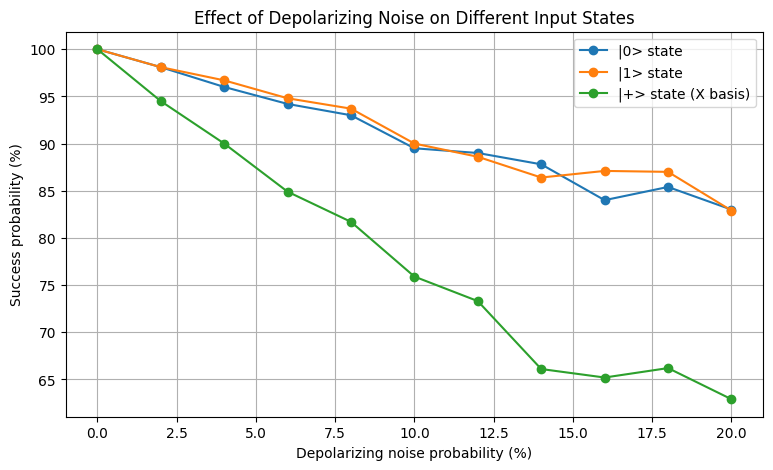

In [ ]:
# ============================================================
# EXPERIMENT 3 — INPUT STATES UNDER DEPOLARIZING NOISE
# ============================================================

# Simulator
simulator = AerSimulator()

# ------------------------------------------------------------
# 1. CREATE |0> TELEPORTATION CIRCUIT
# ------------------------------------------------------------

qc_0 = QuantumCircuit(3, 3)

# |0> is the default state, so no preparation gate needed

# Bell pair
qc_0.h(1)
qc_0.cx(1, 2)

# Alice's operations
qc_0.cx(0, 1)
qc_0.h(0)

# Alice's measurements
qc_0.measure(0, 0)
qc_0.measure(1, 1)

# Bob's corrections
with qc_0.if_test((qc_0.clbits[1], True)):
    qc_0.x(2)

with qc_0.if_test((qc_0.clbits[0], True)):
    qc_0.z(2)

# Bob's measurement
qc_0.measure(2, 2)


# ------------------------------------------------------------
# 2. NOISE LEVELS
# ------------------------------------------------------------

noise_levels_3 = np.arange(0, 0.21, 0.02)

success_0 = []
success_1 = []
success_plus = []


# ------------------------------------------------------------
# 3. RUN ALL THREE INPUT STATES
# ------------------------------------------------------------

for p in noise_levels_3:

    # Create depolarizing noise model
    noise_model = NoiseModel()

    dep_1q = depolarizing_error(p, 1)
    dep_2q = depolarizing_error(p, 2)

    noise_model.add_all_qubit_quantum_error(
        dep_1q, ['h']
    )

    noise_model.add_all_qubit_quantum_error(
        dep_2q, ['cx']
    )


    # ========================================================
    # |0> STATE
    # ========================================================

    result_0 = simulator.run(
        qc_0,
        shots=1000,
        noise_model=noise_model
    ).result()

    counts_0 = result_0.get_counts()

    correct_0 = sum(
        count
        for state, count in counts_0.items()
        if state[0] == '0'
    )

    success_0.append(correct_0 / 1000)


    # ========================================================
    # |1> STATE
    # ========================================================

    result_1 = simulator.run(
        qc_1,
        shots=1000,
        noise_model=noise_model
    ).result()

    counts_1 = result_1.get_counts()

    correct_1 = sum(
        count
        for state, count in counts_1.items()
        if state[0] == '1'
    )

    success_1.append(correct_1 / 1000)


    # ========================================================
    # |+> STATE — X BASIS
    # ========================================================

    result_plus = simulator.run(
        qc_plus_x,
        shots=1000,
        noise_model=noise_model
    ).result()

    counts_plus = result_plus.get_counts()

    # Bob = 0 means + in the X basis
    correct_plus = sum(
        count
        for state, count in counts_plus.items()
        if state[0] == '0'
    )

    success_plus.append(correct_plus / 1000)


# ------------------------------------------------------------
# 4. PRINT RESULTS
# ------------------------------------------------------------

print("Noise levels:")
print(noise_levels_3)

print("\n|0> success rates:")
print(success_0)

print("\n|1> success rates:")
print(success_1)

print("\n|+> X-basis success rates:")
print(success_plus)


# ------------------------------------------------------------
# 5. CREATE COMPARISON GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    noise_levels_3 * 100,
    np.array(success_0) * 100,
    marker='o',
    label='|0> state'
)

plt.plot(
    noise_levels_3 * 100,
    np.array(success_1) * 100,
    marker='o',
    label='|1> state'
)

plt.plot(
    noise_levels_3 * 100,
    np.array(success_plus) * 100,
    marker='o',
    label='|+> state (X basis)'
)

plt.xlabel("Depolarizing noise probability (%)")
plt.ylabel("Success probability (%)")
plt.title("Effect of Depolarizing Noise on Different Input States")

plt.legend()
plt.grid(True)

plt.savefig(
    "input_state_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

|0>: [1.0, 0.961, 0.969, 0.941, 0.93, 0.898, 0.885, 0.888, 0.843, 0.836, 0.833]
|1>: [1.0, 0.984, 0.955, 0.939, 0.93, 0.898, 0.882, 0.869, 0.867, 0.839, 0.801]
|+>: [1.0, 0.955, 0.901, 0.85, 0.812, 0.786, 0.761, 0.75, 0.71, 0.701, 0.65]


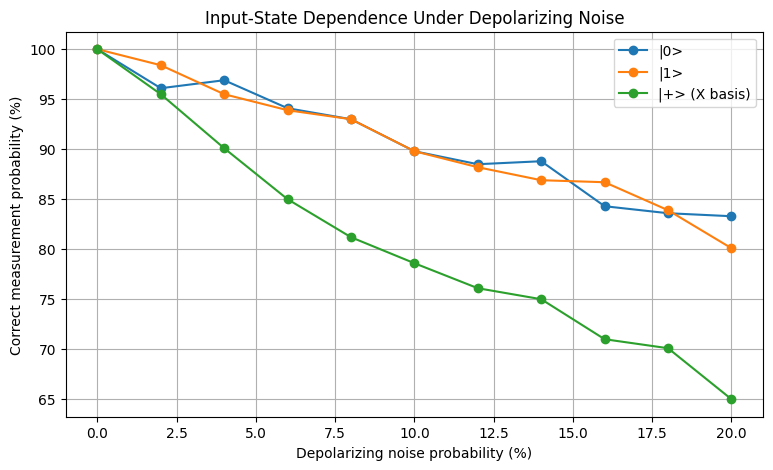

In [ ]:
# ============================================================
# FAIR INPUT-STATE COMPARISON
# Depolarizing noise: 0% -> 20%
# ============================================================

noise_levels_fair = np.arange(0, 0.21, 0.02)

success_0_fair = []
success_1_fair = []
success_plus_fair = []

simulator = AerSimulator()

for p in noise_levels_fair:

    # --------------------------------------------------------
    # Noise model
    # --------------------------------------------------------
    noise_model = NoiseModel()

    dep_1q = depolarizing_error(p, 1)
    dep_2q = depolarizing_error(p, 2)

    noise_model.add_all_qubit_quantum_error(
        dep_1q, ['h']
    )

    noise_model.add_all_qubit_quantum_error(
        dep_2q, ['cx']
    )

    # ========================================================
    # |0> STATE
    # ========================================================

    qc0 = QuantumCircuit(3, 3)

    qc0.initialize([1, 0], 0)

    qc0.h(1)
    qc0.cx(1, 2)

    qc0.cx(0, 1)
    qc0.h(0)

    qc0.measure(0, 0)
    qc0.measure(1, 1)

    with qc0.if_test((qc0.clbits[1], True)):
        qc0.x(2)

    with qc0.if_test((qc0.clbits[0], True)):
        qc0.z(2)

    qc0.measure(2, 2)

    result0 = simulator.run(
        qc0,
        shots=1000,
        noise_model=noise_model
    ).result()

    counts0 = result0.get_counts()

    success_0_fair.append(
        sum(
            count for state, count in counts0.items()
            if state[0] == '0'
        ) / 1000
    )


    # ========================================================
    # |1> STATE
    # ========================================================

    qc1 = QuantumCircuit(3, 3)

    qc1.initialize([0, 1], 0)

    qc1.h(1)
    qc1.cx(1, 2)

    qc1.cx(0, 1)
    qc1.h(0)

    qc1.measure(0, 0)
    qc1.measure(1, 1)

    with qc1.if_test((qc1.clbits[1], True)):
        qc1.x(2)

    with qc1.if_test((qc1.clbits[0], True)):
        qc1.z(2)

    qc1.measure(2, 2)

    result1 = simulator.run(
        qc1,
        shots=1000,
        noise_model=noise_model
    ).result()

    counts1 = result1.get_counts()

    success_1_fair.append(
        sum(
            count for state, count in counts1.items()
            if state[0] == '1'
        ) / 1000
    )


    # ========================================================
    # |+> STATE
    # ========================================================

    qcplus = QuantumCircuit(3, 3)

    # |+> = (|0> + |1>) / sqrt(2)
    qcplus.initialize(
        [1 / np.sqrt(2), 1 / np.sqrt(2)],
        0
    )

    qcplus.h(1)
    qcplus.cx(1, 2)

    qcplus.cx(0, 1)
    qcplus.h(0)

    qcplus.measure(0, 0)
    qcplus.measure(1, 1)

    with qcplus.if_test((qcplus.clbits[1], True)):
        qcplus.x(2)

    with qcplus.if_test((qcplus.clbits[0], True)):
        qcplus.z(2)

    # X-basis measurement
    qcplus.h(2)
    qcplus.measure(2, 2)

    resultplus = simulator.run(
        qcplus,
        shots=1000,
        noise_model=noise_model
    ).result()

    countsplus = resultplus.get_counts()

    success_plus_fair.append(
        sum(
            count for state, count in countsplus.items()
            if state[0] == '0'
        ) / 1000
    )


# ============================================================
# PRINT RESULTS
# ============================================================

print("|0>:", success_0_fair)
print("|1>:", success_1_fair)
print("|+>:", success_plus_fair)


# ============================================================
# GRAPH
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    noise_levels_fair * 100,
    np.array(success_0_fair) * 100,
    marker='o',
    label='|0>'
)

plt.plot(
    noise_levels_fair * 100,
    np.array(success_1_fair) * 100,
    marker='o',
    label='|1>'
)

plt.plot(
    noise_levels_fair * 100,
    np.array(success_plus_fair) * 100,
    marker='o',
    label='|+> (X basis)'
)

plt.xlabel("Depolarizing noise probability (%)")
plt.ylabel("Correct measurement probability (%)")
plt.title("Input-State Dependence Under Depolarizing Noise")

plt.legend()
plt.grid(True)

plt.savefig(
    "input_state_comparison_fair.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

|0> fidelity:
[1.0, 0.981, 0.962, 0.9319999999999999, 0.9349999999999999, 0.9159999999999999, 0.884, 0.893, 0.852, 0.8340000000000001, 0.8300000000000001]

|1> fidelity:
[1.0, 0.98, 0.97, 0.9319999999999999, 0.929, 0.908, 0.898, 0.867, 0.852, 0.865, 0.8240000000000001]

|+> fidelity:
[0.9999999999999997, 0.9569999999999997, 0.9279999999999998, 0.8909999999999997, 0.8429999999999997, 0.8289999999999998, 0.7989999999999999, 0.7999999999999997, 0.7469999999999998, 0.7129999999999999, 0.7079999999999997]


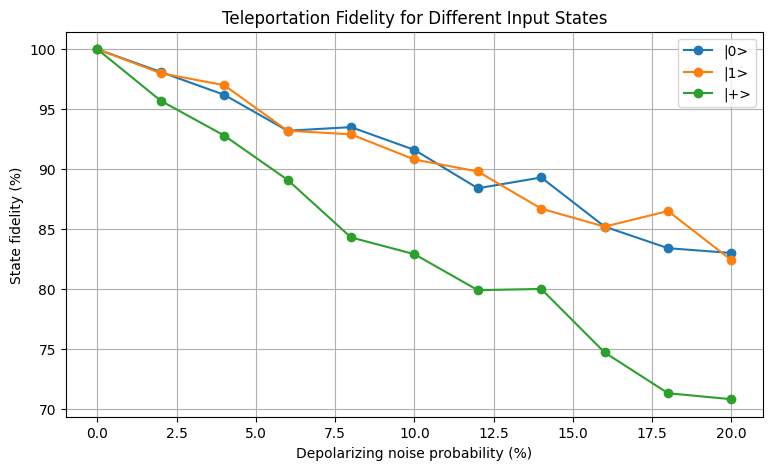

In [ ]:
from qiskit.quantum_info import DensityMatrix, Statevector, partial_trace, state_fidelity

fidelity_0 = []
fidelity_1 = []
fidelity_plus = []

for p in noise_levels_fair:

    # --------------------------------------------------------
    # Noise model
    # --------------------------------------------------------
    noise_model = NoiseModel()

    dep_1q = depolarizing_error(p, 1)
    dep_2q = depolarizing_error(p, 2)

    noise_model.add_all_qubit_quantum_error(dep_1q, ['h'])
    noise_model.add_all_qubit_quantum_error(dep_2q, ['cx'])


    # ========================================================
    # FUNCTION TO BUILD TELEPORTATION CIRCUIT
    # ========================================================

    def teleport_circuit(state):
        qc = QuantumCircuit(3, 2)

        # Prepare input state
        qc.initialize(state, 0)

        # Bell pair
        qc.h(1)
        qc.cx(1, 2)

        # Alice's operations
        qc.cx(0, 1)
        qc.h(0)

        # Alice's measurements
        qc.measure(0, 0)
        qc.measure(1, 1)

        # Bob's corrections
        with qc.if_test((qc.clbits[1], True)):
            qc.x(2)

        with qc.if_test((qc.clbits[0], True)):
            qc.z(2)

        # Save Bob's state BEFORE measurement
        qc.save_density_matrix()

        return qc


    # ========================================================
    # TARGET STATES
    # ========================================================

    states = {
        "0": [1, 0],
        "1": [0, 1],
        "+": [1 / np.sqrt(2), 1 / np.sqrt(2)]
    }


    # ========================================================
    # |0>
    # ========================================================

    qc = teleport_circuit(states["0"])

    result = simulator.run(
        qc,
        shots=1000,
        noise_model=noise_model
    ).result()

    rho = result.data(0)["density_matrix"]

    # Keep only Bob's qubit (q2)
    bob_rho = partial_trace(rho, [0, 1])

    target = Statevector(states["0"])

    fidelity_0.append(
        state_fidelity(bob_rho, target)
    )


    # ========================================================
    # |1>
    # ========================================================

    qc = teleport_circuit(states["1"])

    result = simulator.run(
        qc,
        shots=1000,
        noise_model=noise_model
    ).result()

    rho = result.data(0)["density_matrix"]

    bob_rho = partial_trace(rho, [0, 1])

    target = Statevector(states["1"])

    fidelity_1.append(
        state_fidelity(bob_rho, target)
    )


    # ========================================================
    # |+>
    # ========================================================

    qc = teleport_circuit(states["+"])

    result = simulator.run(
        qc,
        shots=1000,
        noise_model=noise_model
    ).result()

    rho = result.data(0)["density_matrix"]

    bob_rho = partial_trace(rho, [0, 1])

    target = Statevector(states["+"])

    fidelity_plus.append(
        state_fidelity(bob_rho, target)
    )


# ============================================================
# PRINT RESULTS
# ============================================================

print("|0> fidelity:")
print(fidelity_0)

print("\n|1> fidelity:")
print(fidelity_1)

print("\n|+> fidelity:")
print(fidelity_plus)


# ============================================================
# GRAPH
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    noise_levels_fair * 100,
    np.array(fidelity_0) * 100,
    marker='o',
    label='|0>'
)

plt.plot(
    noise_levels_fair * 100,
    np.array(fidelity_1) * 100,
    marker='o',
    label='|1>'
)

plt.plot(
    noise_levels_fair * 100,
    np.array(fidelity_plus) * 100,
    marker='o',
    label='|+>'
)

plt.xlabel("Depolarizing noise probability (%)")
plt.ylabel("State fidelity (%)")
plt.title("Teleportation Fidelity for Different Input States")

plt.legend()
plt.grid(True)

plt.savefig(
    "input_state_fidelity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()